In [14]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

In [15]:
# Step 1: Load Dataset 
df = pd.read_csv("cleaned_sales_data.csv" )

In [16]:
# Step 2: Data Preprocessing
df['Date'] = pd.to_datetime(df['Date'])  # Convert Date column to datetime format
df.dropna(inplace=True)  # Remove missing values
df = df.sort_values(by='Date')  # Ensure data is sorted chronologically

In [17]:
# Step 3: Aggregate sales by month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby(['Year', 'Month'])['Total'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(day=1))
monthly_sales.set_index('Date', inplace=True)
monthly_sales.drop(columns=['Year', 'Month'], inplace=True)

In [18]:
# Step 4: Train-Test Split (80% train, 20% test)
train_size = int(len(monthly_sales) * 0.8)
train, test = monthly_sales.iloc[:train_size], monthly_sales.iloc[train_size:]

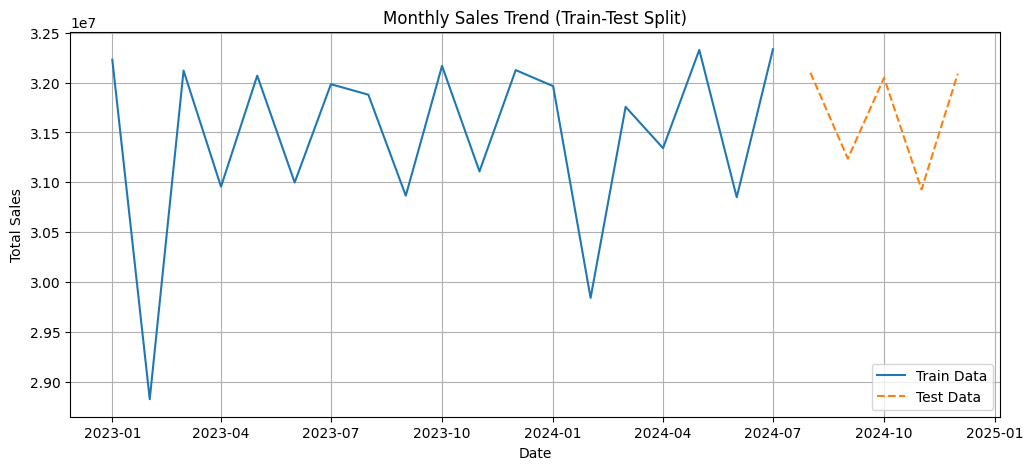

In [19]:
# Step 5: Visualize Sales Trend
plt.figure(figsize=(12,5))
plt.plot(train, label="Train Data")
plt.plot(test, label="Test Data", linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend (Train-Test Split)")
plt.legend()
plt.grid()
plt.show()

In [20]:
# Step 6: Train ARIMA Model on Train Data
model_arima = ARIMA(train['Total'], order=(5,1,0))
model_arima_fit = model_arima.fit()

# Predict on Test Data
y_pred_arima = model_arima_fit.forecast(steps=len(test))
mae_arima = mean_absolute_error(test['Total'], y_pred_arima)

print("📊 ARIMA Model - Mean Absolute Error (MAE):", round(mae_arima, 2))

📊 ARIMA Model - Mean Absolute Error (MAE): 481727.01


C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [21]:
# Step 8: Predict Next Month's Sales
next_month_arima = model_arima_fit.forecast(steps=1)[0]

print("\n🔹 ARIMA Predicted Sales for Next Month:", round(next_month_arima, 2))


🔹 ARIMA Predicted Sales for Next Month: 31999469.9


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14208\283416727.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_month_arima = model_arima_fit.forecast(steps=1)[0]


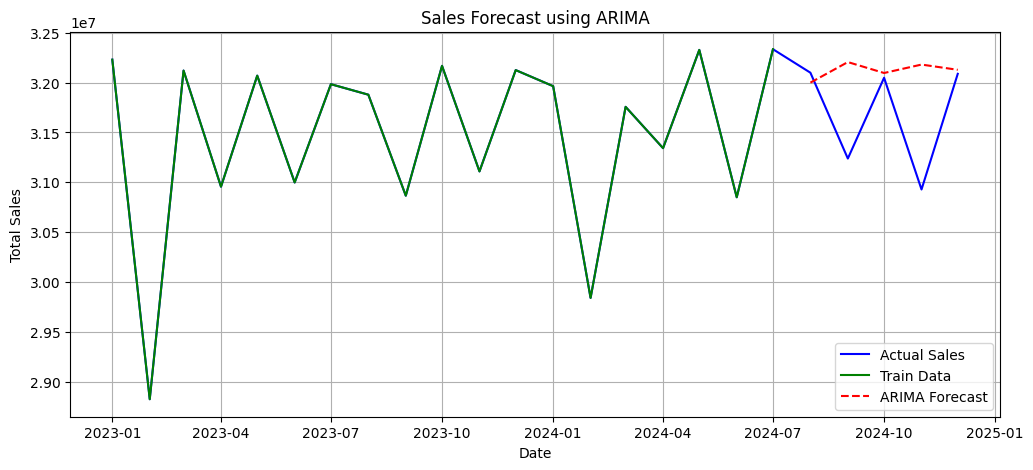

In [22]:
# Step 9: Plot ARIMA Forecast
plt.figure(figsize=(12, 5))

# Plot actual sales data
plt.plot(monthly_sales.index, monthly_sales['Total'], label="Actual Sales", color="blue")

# Plot train data
plt.plot(train.index, train['Total'], label="Train Data", color="green")

# Plot ARIMA forecast
plt.plot(test.index, y_pred_arima, label="ARIMA Forecast", color="red", linestyle="dashed")

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Sales Forecast using ARIMA")
plt.legend()
plt.grid()
plt.show()
